In [37]:
# --- Step 0: Setup and load the raw stock panel ---
# PCA needs a clean numeric matrix later. Here we only load and tidy the CSV:
# one row per (date, ticker) with OHLCV. We fix the bad first line and parse dates.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler  # mean-center + scale each feature (column)
from sklearn.decomposition import PCA  # implements PCA via SVD (same idea as eig(cov))

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
pd.options.display.float_format = "{:.4f}".format

CSV_PATH = "all_stocks_5yr.csv"
COLS = ["date", "open", "high", "low", "close", "volume", "Name"]

# Skip row 0: file often starts with junk; we supply column names ourselves.
raw = pd.read_csv(CSV_PATH, header=None, skiprows=1, names=COLS, low_memory=False)

raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date", "close"])  # need valid time and price

# Ticker cleanup so pivot keys are consistent (drops odd characters like "AAL≈").
raw["Name"] = (
    raw["Name"].astype(str).str.strip().str.replace(r"[^A-Za-z0-9]", "", regex=True)
)
raw = raw[raw["Name"].str.len() > 0]

print(raw.shape)
print(raw.dtypes)
print("Unique tickers:", raw["Name"].nunique())
print(raw.head())


(619031, 7)
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object
Unique tickers: 505
        date    open    high     low   close   volume Name
0 2013-02-22 13.5700 13.6000 13.2100 13.5700  6071400  AAL
1 2013-02-25 13.6000 13.7600 13.0000 13.0200  7186400  AAL
2 2013-02-26 13.1400 13.4200 12.7000 13.2600  9419000  AAL
3 2013-02-27 13.2800 13.6200 13.1800 13.4100  7390500  AAL
4 2013-02-28 13.4900 13.6300 13.3900 13.4300  6143600  AAL


In [38]:
# --- Step 1: Build the data matrix X we will feed to PCA ---
# Rows = trading days, columns = stocks, values = daily returns (not raw prices).
# PCA is sensitive to scale: returns put every stock in "return space" first.
# We drop illiquid/short-history names and keep only dates where ALL kept stocks trade.

prices = raw.pivot_table(index="date", columns="Name", values="close", aggfunc="last")
prices = prices.sort_index().sort_index(axis=1)

# Daily simple return: (P_t / P_{t-1}) - 1. First day per column is NaN → drop it.
returns = prices.div(prices.shift(1)).sub(1.0).iloc[1:]

min_obs = 500  # only keep stocks with enough history (otherwise mostly missing)
valid_cols = returns.columns[returns.notna().sum() >= min_obs]
returns = returns[valid_cols]

# Balanced panel: one row only if every stock has a return that day (no fill).
returns = returns.dropna(axis=0, how="any")

print("Shape (days × tickers):", returns.shape)
print("Date range:", returns.index.min(), "→", returns.index.max())


Shape (days × tickers): (525, 496)
Date range: 2016-01-06 00:00:00 → 2018-02-07 00:00:00


In [39]:
# --- Step 2: Preprocess (mean normalization + feature scaling) ---
# Course slides: subtract mean per feature, then divide by scale (e.g. std).
# That makes PCA on X_scaled match "correlation PCA": no stock dominates only
# because it is more volatile than others.

X = returns.to_numpy(dtype=float)  # still named X; each column is one stock over time
feature_names = returns.columns.to_list()
index_dates = returns.index

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)  # column j → (x_j - mean_j) / std_j

# PCA breaks if a column is constant (zero variance after scaling).
assert not np.any(np.std(X_scaled, axis=0) < 1e-12), "Drop constant columns before PCA"

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (525, 496)


In [40]:
# --- Step 3: Covariance matrix and link to principal components ---
# Theory: after centering/scaling, form sample covariance S (p×p).
# Principal directions are eigenvectors of S; eigenvalues = variance along each PC.
# sklearn.PCA actually uses SVD on X_scaled (more stable than forming huge S when p is big).

n_days, p = X_scaled.shape

S = np.cov(X_scaled, rowvar=False, bias=False)  # rowvar=False → each column is a variable (stock)
print("Covariance matrix shape:", S.shape)

# Fit PCA with all components (up to min(n_days, p)) so we can pick k later from full variance.
pca_full = PCA(n_components=min(n_days, p), svd_solver="full")
pca_full.fit(X_scaled)
ev_sklearn = pca_full.explained_variance_  # eigenvalues of covariance (up to scaling)

# Sanity check: eigenvalues from np.linalg.eigh(S) should match sklearn's explained_variance_.
w, V = np.linalg.eigh(S)  # eigh returns ascending order
w = np.sort(w)[::-1]
print("Max |diff| eigenvalues (np vs sklearn), first 10:",
      np.max(np.abs(w[:10] - ev_sklearn[:10])))

# Small printed block: see correlations between the first few standardized return series.
k_show = min(5, p)
block = X_scaled[:, :k_show]
S_block = np.cov(block, rowvar=False, bias=False)
print("5×5 covariance block (first tickers):")
print(np.round(S_block, 6))


Covariance matrix shape: (496, 496)
Max |diff| eigenvalues (np vs sklearn), first 10: 7.105427357601002e-14
5×5 covariance block (first tickers):
[[1.001908 0.401713 0.112176 0.359064 0.366071]
 [0.401713 1.001908 0.168308 0.289131 0.175965]
 [0.112176 0.168308 1.001908 0.08139  0.120563]
 [0.359064 0.289131 0.08139  1.001908 0.192947]
 [0.366071 0.175965 0.120563 0.192947 1.001908]]


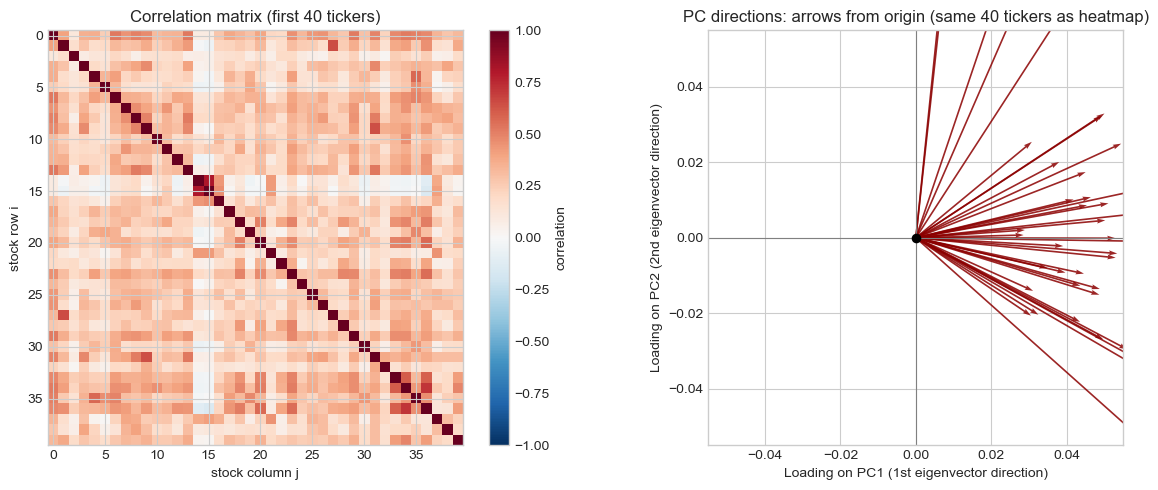

In [41]:
# --- Plot: correlation matrix + PC directions (loadings) ---
# Heatmap: pairwise correlation of standardized returns (same scale idea as correlation PCA).
# Right panel: each arrow is one stock's direction in the (PC1, PC2) plane — the first two
# eigenvectors of the covariance matrix. Longer arrows = that stock contributes more to those PCs.

n_show = min(40, p)
R = np.corrcoef(X_scaled[:, :n_show], rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(R, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[0].set_title("Correlation matrix (first {:d} tickers)".format(n_show))
axes[0].set_xlabel("stock column j")
axes[0].set_ylabel("stock row i")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="correlation")

step = max(1, n_show // 8)
axes[0].set_xticks(np.arange(0, n_show, step))
axes[0].set_yticks(np.arange(0, n_show, step))

L1 = pca_full.components_[0]
L2 = pca_full.components_[1]

axes[1].axhline(0.0, color="gray", lw=0.8)
axes[1].axvline(0.0, color="gray", lw=0.8)
axes[1].scatter(0.0, 0.0, c="black", s=35, zorder=5, label="origin")

axes[1].quiver(
    np.zeros(n_show),
    np.zeros(n_show),
    L1[:n_show],
    L2[:n_show],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.85,
    color="darkred",
)
axes[1].set_xlabel("Loading on PC1 (1st eigenvector direction)")
axes[1].set_ylabel("Loading on PC2 (2nd eigenvector direction)")
axes[1].set_title("PC directions: arrows from origin (same {:d} tickers as heatmap)".format(n_show))
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

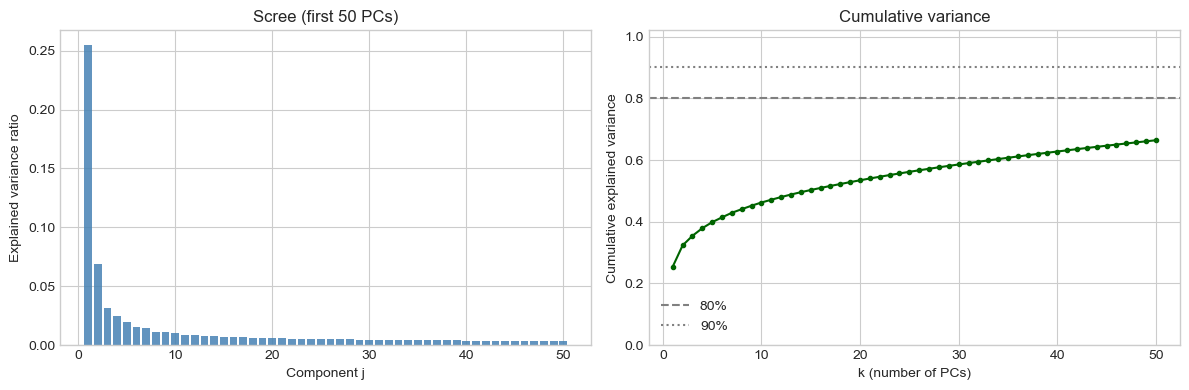

Smallest k with cumulative variance ≥ 80%: k = 103
Smallest k with cumulative variance ≥ 90%: k = 170
Kaiser (eigenvalue > 1) counts 101 PCs (max possible min(n,p) = 496).


In [42]:
# --- Step 4: Choose how many components k to keep ---
# Slides: pick smallest k so enough variance is retained (e.g. 99%); we use 80%/90% here.
# Scree plot: where the bars "bend" is informal. Cumulative curve: exact k for a % target.
# Kaiser rule (correlation PCA): count eigenvalues > 1 — rough, often many for big p.

n_comp_plot = max(1, min(50, min(n_days, p)))  # only plot first PCs so the figure is readable
pca_plot = PCA(n_components=n_comp_plot, svd_solver="full")
pca_plot.fit(X_scaled)

ratios = pca_plot.explained_variance_ratio_  # each PC's share of total variance
cumul = np.cumsum(ratios)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, len(ratios) + 1), ratios, color="steelblue", alpha=0.85)
axes[0].set_xlabel("Component j")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree (first {:d} PCs)".format(n_comp_plot))

axes[1].plot(np.arange(1, len(cumul) + 1), cumul, marker=".", color="darkgreen")
axes[1].axhline(0.80, color="gray", linestyle="--", label="80%")
axes[1].axhline(0.90, color="gray", linestyle=":", label="90%")
axes[1].set_xlabel("k (number of PCs)")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance")
axes[1].legend()
axes[1].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

# k from FULL spectrum (pca_full), not only the first 50 plotted bars.
cumul_full = np.cumsum(pca_full.explained_variance_ratio_)
for target in (0.80, 0.90):
    k_target = int(np.searchsorted(cumul_full, target) + 1)
    print("Smallest k with cumulative variance ≥ {:.0%}: k = {}".format(target, k_target))

eigenvals = pca_full.explained_variance_
kaiser_k = int(np.sum(eigenvals > 1.0))
print(
    "Kaiser (eigenvalue > 1) counts",
    kaiser_k,
    "PCs (max possible min(n,p) = {:.0f}).".format(len(eigenvals)),
)


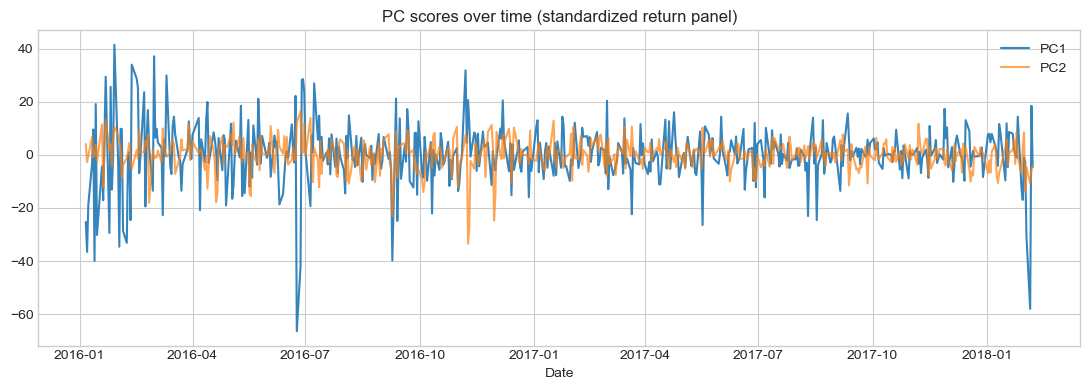

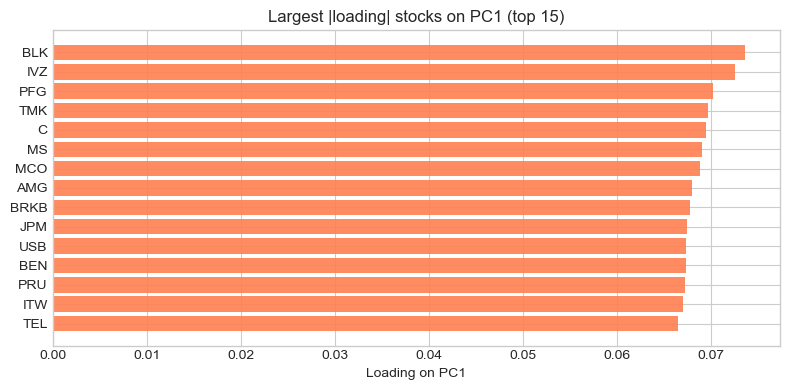

In [43]:
# --- Step 5: Project data onto a few PCs and interpret (visualization) ---
# Course idea: z = projection of each row of X onto the chosen directions (here: first k PCs).
# Scores Z[t, :] = coordinates of day t in PC space. This is NOT regression: no y target;
# we minimize orthogonal projection error in feature space (all stocks treated symmetrically).
# For 2D/3D plots, k is usually 2 or 3 even if variance needs more PCs for compression.

k_interp = min(3, min(n_days, p))  # small k for plotting; increase if you only care about variance

pca_k = PCA(n_components=k_interp, svd_solver="full")
Z = pca_k.fit_transform(X_scaled)  # shape (n_days, k_interp) = PC scores over time

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(index_dates, Z[:, 0], label="PC1", alpha=0.9)
if k_interp >= 2:
    ax.plot(index_dates, Z[:, 1], label="PC2", alpha=0.7)
ax.set_title("PC scores over time (standardized return panel)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

# Loadings: components_[0, j] = how much stock j contributes to PC1 (like slide direction u^(1)).
load1 = pca_k.components_[0]
order = np.argsort(np.abs(load1))[::-1][:15]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.array(feature_names)[order][::-1], load1[order][::-1], color="coral", alpha=0.9)
ax.set_xlabel("Loading on PC1")
ax.set_title("Largest |loading| stocks on PC1 (top 15)")
plt.tight_layout()
plt.show()


Silhouette scores for K = [2, 3, 4, 5, 6, 7, 8, 9, 10]
[0.1852 0.115  0.1604 0.1651 0.1754 0.1943 0.2393 0.2549 0.2581]
Chosen K (max silhouette): 10
Stocks per cluster: {0: np.int64(74), 1: np.int64(56), 2: np.int64(61), 3: np.int64(26), 4: np.int64(116), 5: np.int64(32), 6: np.int64(29), 7: np.int64(47), 8: np.int64(26), 9: np.int64(29)}


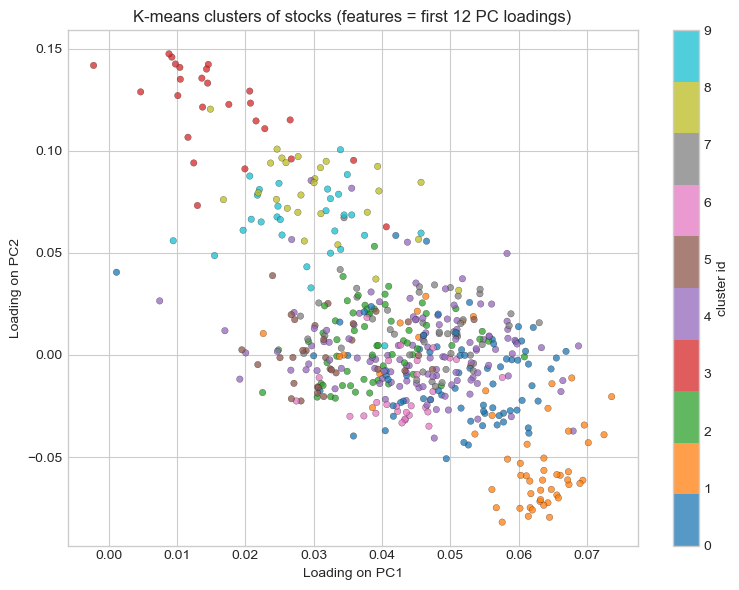

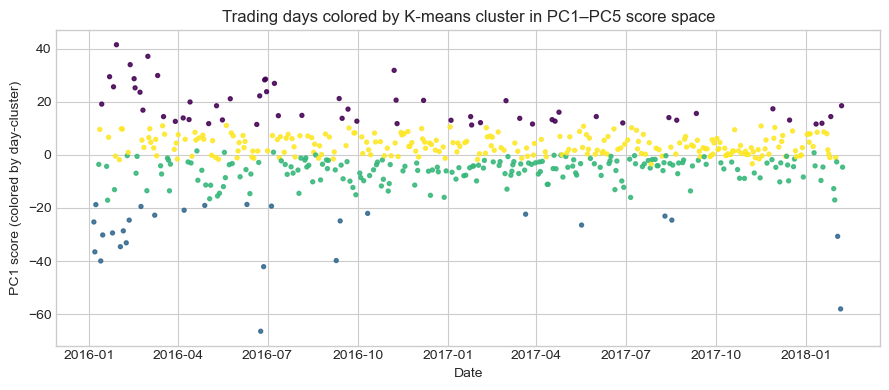

In [44]:
# --- Step 6: K-means on PC loadings (stocks) + optional K-means on PC scores (days) ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Number of PCs used as features for clustering (balance: signal vs noise)
m_clust = min(12, pca_full.n_components_)
# Each stock j gets a row: [loading on PC1, ..., loading on PCm]
stock_features = pca_full.components_[:m_clust, :].T  # shape (p, m_clust)

# Search a modest range of K; pick K with best silhouette (well-separated clusters)
k_min, k_max = 2, min(10, max(3, p // 30))
k_candidates = range(k_min, k_max + 1)
silhouettes = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(stock_features)
    silhouettes.append(silhouette_score(stock_features, labels_k))

best_k = list(k_candidates)[int(np.argmax(silhouettes))]
print("Silhouette scores for K =", list(k_candidates))
print(np.round(silhouettes, 4))
print("Chosen K (max silhouette):", best_k)

km_stocks = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_stock = km_stocks.fit_predict(stock_features)

# Sizes per cluster
_, counts = np.unique(cluster_stock, return_counts=True)
print("Stocks per cluster:", dict(zip(range(best_k), counts)))

# Plot: first two PC loadings as axes, color = cluster
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    stock_features[:, 0],
    stock_features[:, 1],
    c=cluster_stock,
    cmap="tab10",
    alpha=0.75,
    s=22,
    edgecolors="k",
    linewidths=0.2,
)
ax.set_xlabel("Loading on PC1")
ax.set_ylabel("Loading on PC2")
ax.set_title("K-means clusters of stocks (features = first {:d} PC loadings)".format(m_clust))
plt.colorbar(scatter, ax=ax, label="cluster id")
plt.tight_layout()
plt.show()

# --- Optional: cluster days in PC-score space (first few PCs) ---
m_days = min(5, pca_full.n_components_)
day_scores = pca_full.transform(X_scaled)[:, :m_days]  # shape (n_days, m_days)
k_days = min(4, max(2, n_days // 100))  # small K for interpretability
km_days = KMeans(n_clusters=k_days, random_state=42, n_init=10)
cluster_day = km_days.fit_predict(day_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(index_dates, day_scores[:, 0], c=cluster_day, cmap="viridis", s=8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("PC1 score (colored by day-cluster)")
ax.set_title("Trading days colored by K-means cluster in PC1–PC{:d} score space".format(m_days))
plt.tight_layout()
plt.show()